In [1]:
input_file = '/home/ajarrah/PhD_Thesis/chapter_3/aggregated_h5ad_data/aggregated_mouse_brain_202502.h5ad'
input_folder = "/home/ajarrah/PhD_Thesis/chapter_3/h5ad_data/"
output_folder = "/home/ajarrah/PhD_Thesis/chapter_4/h5ad_data/genes_top_800"


In [2]:
# Core scverse libraries
import scanpy as sc
import numpy as np
import pandas as pd
import os
import numpy as np

# Data retrieval
import pooch

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

In [3]:
adata = sc.read_h5ad(input_file)

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
aad_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Aged_AD_Mouse_Brain_202502.h5ad"))
aad_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Aged_AD_Mouse_Brain_202502.h5ad"))
aad_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Aged_AD_Mouse_Brain_202502.h5ad"))
aad_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Aged_AD_Mouse_Brain_202502.h5ad"))
ac_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Aged_Control_Mouse_Brain_202502.h5ad"))
ac_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Aged_Control_Mouse_Brain_202502.h5ad"))
ac_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Aged_Control_Mouse_Brain_202502.h5ad"))
ac_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Aged_Control_Mouse_Brain_202502.h5ad"))
yad_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Young_AD_Mouse_Brain_202502.h5ad"))
yad_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Young_AD_Mouse_Brain_202502.h5ad"))
yad_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Young_AD_Mouse_Brain_202502.h5ad"))
yad_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Young_AD_Mouse_Brain_202502.h5ad"))
yc_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Young_Control_Mouse_Brain_202502.h5ad"))
yc_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Young_Control_Mouse_Brain_202502.h5ad"))
yc_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Young_Control_Mouse_Brain_202502.h5ad"))
yc_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Young_Control_Mouse_Brain_202502.h5ad"))

In [5]:
data_name = [yc_1, yc_2, yc_3, yc_4,
                yad_1, yad_2, yad_3, yad_4,
                ac_1, ac_2, ac_3, ac_4,
                aad_1, aad_2, aad_3, aad_4]

sample_name = ["YC_1", "YC_2", "YC_3", "YC_4",
                "YAD_1", "YAD_2", "YAD_3", "YAD_4",
                "AC_1", "AC_2", "AC_3", "AC_4",
                "AAD_1", "AAD_2", "AAD_3", "AAD_4"]

sample_display_name = ["Young Control 1", "Young Control 2", "Young Control 3", "Young Control 4",
                       "Young AD 1", "Young AD 2", "Young AD 3", "Young AD 4",
                       "Aged Control 1", "Aged Control 2", "Aged Control 3", "Aged Control 4",
                       "Aged AD 1", "Aged AD 2", "Aged AD 3", "Aged AD 4"]

In [6]:

def add_coordinate_in_um(adata, spot_spacing_um=100.0):

    # Vectorized coordinate calculation
    adata.obs["y_um"] = adata.obs["array_row"] * (np.sqrt(3)/2 * spot_spacing_um)
    adata.obs["x_um"] = adata.obs["array_col"] * (spot_spacing_um / 2)

    # Round to 2 decimal places
    adata.obs["x_um"] = adata.obs["x_um"].round(2)
    adata.obs["y_um"] = adata.obs["y_um"].round(2)

    # Return only x/y with barcode as index
    return adata

In [7]:
# Ensure matrix is dense or use .A1 for sparse matrices
if isinstance(adata.X, np.ndarray):
    non_zero_genes = adata.X.sum(axis=0) != 0
else:
    non_zero_genes = np.array((adata.X.sum(axis=0) != 0)).ravel()  # for sparse matrix

adata = adata[:, non_zero_genes].copy()

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:03)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:21)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:18)
running Leiden clustering


/tmp/ipykernel_3607455/1193463051.py:39: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(sc_adata, key_added='leiden')  # or sc.tl.louvain


    finished: found 38 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:27)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:46)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_Group']`


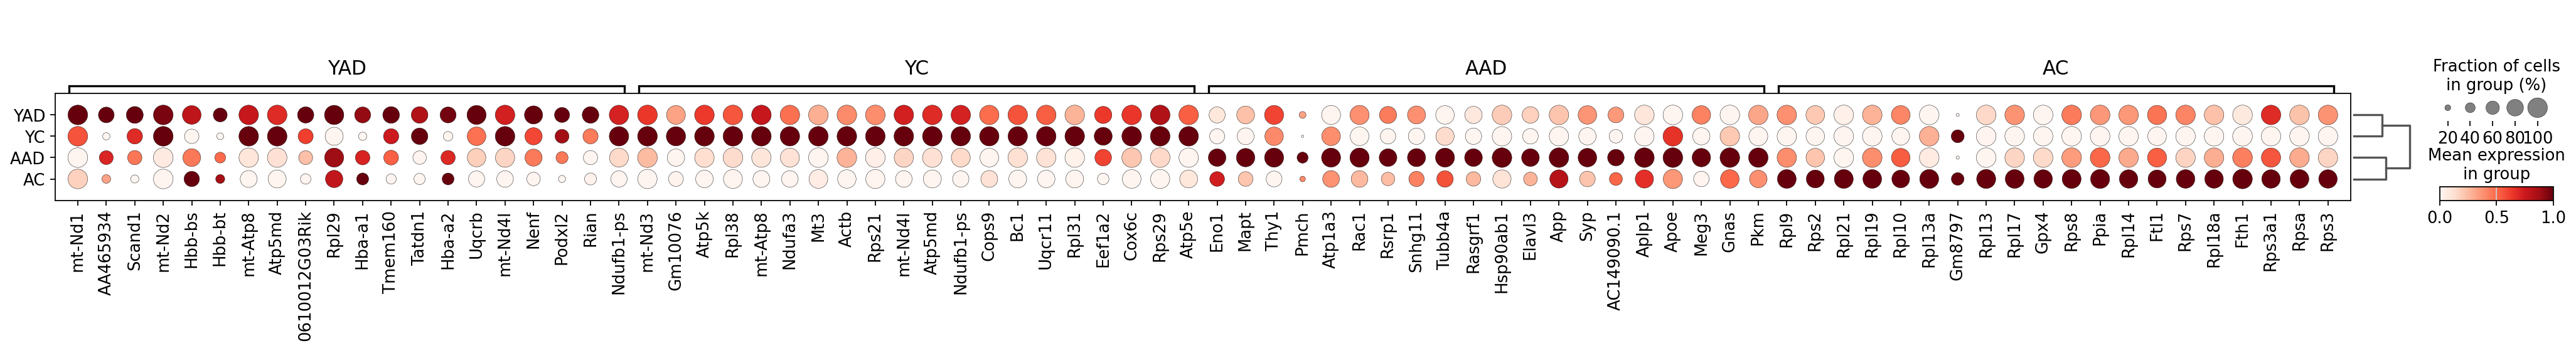

In [8]:

# -------------------------
# Single-cell preprocessing
# -------------------------
sc_adata = adata  # replace path

# Basic QC metrics
sc.pp.calculate_qc_metrics(sc_adata, inplace=True)  # adds n_genes_by_counts, total_counts, pct_counts_{mt, rib}
# If mitochondrial genes are not auto-detected, set them:
# sc_adata.var['mt'] = sc_adata.var_names.str.upper().str.startswith('MT-')  # human style
# sc.pp.calculate_qc_metrics(sc_adata, qc_vars=['mt'], inplace=True)

# 1) Filter cells and genes
#sc.pp.filter_cells(sc_adata, min_genes=200)
#sc.pp.filter_genes(sc_adata, min_cells=3)

# 2) Compute percent mitochondrial (if not already present)
# Common pattern (human: MT- ; mouse: mt- or Mt-). Adjust to your organism.


# 3) Normalize total counts per cell (CPM / library size normalization)
sc.pp.normalize_total(sc_adata, target_sum=1)   # or 1e6 depending on preference

# 4) Log1p transform
sc.pp.log1p(sc_adata)

# 5) Save a raw layer (unscaled) for plotting and rank genes comparisons
sc_adata.raw = sc_adata   # safe copy, raw contains normalized log1p counts

# 6) Identify HVGs
sc.pp.highly_variable_genes(sc_adata, n_top_genes=2000)

# 7) Scale - center and scale (use adata.raw to preserve for plotting)
sc.pp.scale(sc_adata, max_value=10)   # caps extreme values; used for PCA and DE

# 8) PCA, neighbors, clustering
sc.tl.pca(sc_adata, svd_solver='arpack')
sc.pp.neighbors(sc_adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(sc_adata)
sc.tl.leiden(sc_adata, key_added='leiden')  # or sc.tl.louvain

# If you already have a grouping column (e.g., adata.obs['Group']), you can skip clustering.

# 9) Differential expression example (your code)
# Use groupby that you want (e.g. 'Group' or 'leiden' or cell type annotation)
groupby_key = "Group"  # change to your obs column
sc.tl.rank_genes_groups(sc_adata, groupby=groupby_key, method='wilcoxon')
sc.pl.rank_genes_groups_dotplot(sc_adata, groupby=groupby_key, standard_scale='var', n_genes=20)


In [9]:
# Access results
result = sc_adata.uns['rank_genes_groups']
groups = result['names'].dtype.names  # list of group names
top_genes_per_group = {}

for group in groups:
    # Get top 20 genes for this group
    top_genes = result['names'][group][0:200]
    top_genes_per_group[group] = top_genes

# Convert to DataFrame for easy viewing
top_genes_df = pd.DataFrame(top_genes_per_group)
print(top_genes_df)


          AAD             AC       YAD       YC
0        Eno1           Rpl9    mt-Nd1   mt-Nd3
1        Mapt           Rps2  AA465934  Gm10076
2        Thy1          Rpl21    Scand1    Atp5k
3        Pmch          Rpl19    mt-Nd2    Rpl38
4      Atp1a3          Rpl10    Hbb-bs  mt-Atp8
..        ...            ...       ...      ...
195  Hsp90aa1          Jsrp1     Prrt3    Rasd2
196     Pdia3  2900060N12Rik     Lamp5   Mrps21
197    Ddx39b         Ube2l6   Fam162a   Ahcyl1
198     Ndrg2       AW551984      Bag1   Cox6b1
199     Tra2b          Lbhd2     Mcts1   Adam23

[200 rows x 4 columns]


In [18]:
top_genes_df["AAD"][1:20].to_list()

['Mapt',
 'Thy1',
 'Pmch',
 'Atp1a3',
 'Rac1',
 'Rsrp1',
 'Snhg11',
 'Tubb4a',
 'Rasgrf1',
 'Hsp90ab1',
 'Elavl3',
 'App',
 'Syp',
 'AC149090.1',
 'Aplp1',
 'Apoe',
 'Meg3',
 'Gnas',
 'Pkm']

In [10]:
gene_list = []
for group in groups:
    # Get top 20 genes for this group
    top_genes = result['names'][group][0:200]
    gene_list.extend(top_genes)

In [11]:
# Create output directory if it does not exist
os.makedirs(output_folder, exist_ok=True)

for i, ad in enumerate(data_name):

    # Intersect gene_list with existing genes in this sample
    keep_genes = [g for g in gene_list if g in ad.var_names]

    # Subset and replace
    data_name[i] = ad[:, keep_genes].copy()
    data_name[i] = add_coordinate_in_um(data_name[i], spot_spacing_um=100.0).copy()

    # Save file
    data_name[i].write_h5ad(f"{output_folder}/{sample_name[i]}.h5ad")


/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique

In [12]:
data_name[0].obs

,in_tissue,array_row,array_col,Original_Name,Sample_Code,Group,y_um,x_um
AAACACCAATAACTGC-1,1,59,19,A1_Young_Control_Mouse_Brain_202502,1-1,YC,5109.55,950.0
AAACAGGGTCTATATT-1,1,47,13,A1_Young_Control_Mouse_Brain_202502,1-1,YC,4070.32,650.0
AAACAGTGTTCCTGGG-1,1,73,43,A1_Young_Control_Mouse_Brain_202502,1-1,YC,6321.99,2150.0
AAACCGGGTAGGTACC-1,1,42,28,A1_Young_Control_Mouse_Brain_202502,1-1,YC,3637.31,1400.0
AAACCGTTCGTCCAGG-1,1,52,42,A1_Young_Control_Mouse_Brain_202502,1-1,YC,4503.33,2100.0
...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,1,31,77,A1_Young_Control_Mouse_Brain_202502,1-1,YC,2684.68,3850.0
TTGTTTCACATCCAGG-1,1,58,42,A1_Young_Control_Mouse_Brain_202502,1-1,YC,5022.95,2100.0
TTGTTTCATTAGTCTA-1,1,60,30,A1_Young_Control_Mouse_Brain_202502,1-1,YC,5196.15,1500.0
TTGTTTCCATACAACT-1,1,45,27,A1_Young_Control_Mouse_Brain_202502,1-1,YC,3897.11,1350.0
